In [6]:
!pip install torch-snippets

  Using cached torch_snippets-0.560-py3-none-any.whl.metadata (16 kB)
  Using cached loguru-0.7.3-py3-none-any.whl.metadata (22 kB)
  Using cached typing-3.7.4.3.tar.gz (78 kB)
  Preparing metadata (setup.py) ... done
  Using cached jsonlines-4.0.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached imgaug-0.4.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached xmltodict-1.0.3-py3-none-any.whl.metadata (14 kB)
  Using cached python_levenshtein-0.27.3-py3-none-any.whl.metadata (3.9 kB)
  Using cached pre_commit-4.5.1-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached icecream-2.1.10-py3-none-any.whl.metadata (1.5 kB)
  Using cached mergedeep-1.3.4-py3-none-any.whl.metadata (4.3 kB)
  Using cached lovely_tensors-0.1.21-py3-none-any.whl.metadata (17 kB)
  Using cached executing-2.2.1-py2.py3-none-any.whl.metadata (8.9 kB)
  Using cached lovely_numpy-0.2.18-py3-none-any.whl.metadata (10 kB)
  Using cached cfgv-3.5.0-py2.py3-none-any.whl.metadata (8.9 kB)
  Using cached identify-2.6.16

# Dataset Analysis

In [7]:
# Import Libraries and Setup
import os
import torch, torch.nn as nn
from torchsummary import summary
from torch_snippets import *
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {DEVICE}')

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using: cuda


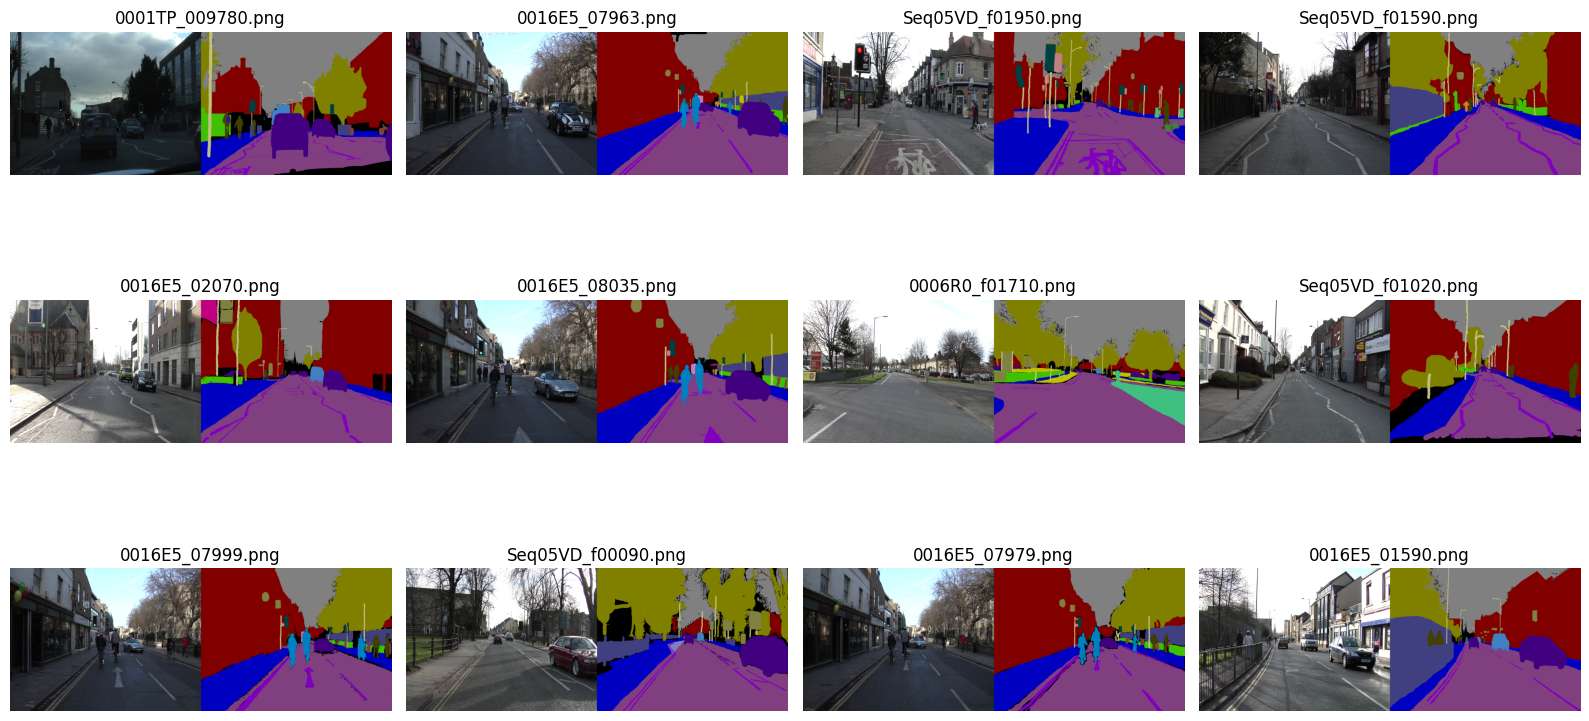

Zip file saved at: /kaggle/working/visualized_samples.zip


In [8]:
#Visualize Sample Images with Masks and save output as zip file

import shutil

DATA_DIR = "/kaggle/input/camvid/CamVid"

#Visualize Sample Images with Masks

nrows, ncols = 3, 4
plt.figure(figsize=(ncols*4, nrows*3))
count = 0

# Create output directory
SAVE_DIR = "/kaggle/working/visualized_samples"
os.makedirs(SAVE_DIR, exist_ok=True)

for id in os.listdir(os.path.join(DATA_DIR, 'train')):
    if count == nrows * ncols:
        break
    count += 1
    img_path = os.path.join(DATA_DIR, 'train', id)
    mask_path = os.path.join(DATA_DIR, 'train_labels', id[:-4] + '_L.png')
    img = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path).convert('RGB')
    
    combined = np.hstack([img, mask])

    # Save the combined image
    save_path = os.path.join(SAVE_DIR, id)
    Image.fromarray(combined).save(save_path)

    plt.subplot(nrows, ncols, count)
    plt.title(id)
    plt.axis('off')
    plt.imshow(combined)

plt.tight_layout()
plt.show()

ZIP_PATH = "/kaggle/working/visualized_samples.zip"
shutil.make_archive("/kaggle/working/visualized_samples", 'zip', SAVE_DIR)

print("Zip file saved at:", ZIP_PATH)

In [9]:
# Check if some images are missing masks

splits = ['train', 'test', 'val']

for split in splits:
    images_dir = os.path.join(DATA_DIR, split)
    masks_dir = os.path.join(DATA_DIR, split + '_labels')

    print(f'Number of images in {split} subset: {len(os.listdir(images_dir))}')
    print(f'Number of masks in {split} subset: {len(os.listdir(masks_dir))}')
    print('-----------------------------------------')

Number of images in train subset: 369
Number of masks in train subset: 369
-----------------------------------------
Number of images in test subset: 232
Number of masks in test subset: 232
-----------------------------------------
Number of images in val subset: 100
Number of masks in val subset: 100
-----------------------------------------


In [10]:
#Define CamVid Color to Class Mapping

camvid_classes = {
    (64, 128, 64): "Animal",
    (192, 0, 128): "Archway",
    (0, 128, 192): "Bicyclist",
    (0, 128, 64): "Bridge",
    (128, 0, 0): "Building",
    (64, 0, 128): "Car",
    (64, 0, 192): "CartLuggagePram",
    (192, 128, 64): "Child",
    (192, 192, 128): "Column_Pole",
    (64, 64, 128): "Fence",
    (128, 0, 192): "LaneMkgsDriv",
    (192, 0, 64): "LaneMkgsNonDriv",
    (128, 128, 64): "Misc_Text",
    (192, 0, 192): "MotorcycleScooter",
    (128, 64, 64): "OtherMoving",
    (64, 192, 128): "ParkingBlock",
    (64, 64, 0): "Pedestrian",
    (128, 64, 128): "Road",
    (128, 128, 192): "RoadShoulder",
    (0, 0, 192): "Sidewalk",
    (192, 128, 128): "SignSymbol",
    (128, 128, 128): "Sky",
    (64, 128, 192): "SUVPickupTruck",
    (0, 0, 64): "TrafficCone",
    (0, 64, 64): "TrafficLight",
    (192, 64, 128): "Train",
    (128, 128, 0): "Tree",
    (192, 128, 192): "Truck_Bus",
    (64, 0, 64): "Tunnel",
    (192, 192, 0): "VegetationMisc",
    (0, 0, 0): "Void",
    (64, 192, 0): "Wall"
}

print("\nColor to Class Mapping:")
print("-" * 50)
for color in sorted(camvid_classes.keys()):
    label = camvid_classes.get(color, 'Unknown')
    print(f"RGB{color} -> {label}")


Color to Class Mapping:
--------------------------------------------------
RGB(0, 0, 0) -> Void
RGB(0, 0, 64) -> TrafficCone
RGB(0, 0, 192) -> Sidewalk
RGB(0, 64, 64) -> TrafficLight
RGB(0, 128, 64) -> Bridge
RGB(0, 128, 192) -> Bicyclist
RGB(64, 0, 64) -> Tunnel
RGB(64, 0, 128) -> Car
RGB(64, 0, 192) -> CartLuggagePram
RGB(64, 64, 0) -> Pedestrian
RGB(64, 64, 128) -> Fence
RGB(64, 128, 64) -> Animal
RGB(64, 128, 192) -> SUVPickupTruck
RGB(64, 192, 0) -> Wall
RGB(64, 192, 128) -> ParkingBlock
RGB(128, 0, 0) -> Building
RGB(128, 0, 192) -> LaneMkgsDriv
RGB(128, 64, 64) -> OtherMoving
RGB(128, 64, 128) -> Road
RGB(128, 128, 0) -> Tree
RGB(128, 128, 64) -> Misc_Text
RGB(128, 128, 128) -> Sky
RGB(128, 128, 192) -> RoadShoulder
RGB(192, 0, 64) -> LaneMkgsNonDriv
RGB(192, 0, 128) -> Archway
RGB(192, 0, 192) -> MotorcycleScooter
RGB(192, 64, 128) -> Train
RGB(192, 128, 64) -> Child
RGB(192, 128, 128) -> SignSymbol
RGB(192, 128, 192) -> Truck_Bus
RGB(192, 192, 0) -> VegetationMisc
RGB(192, 19

In [11]:
#Calculate Class Frequencies 

print("\n\nCalculating Class Frequencies...")
print("-" * 50)

class_counts = defaultdict(int)
train_labels_path = os.path.join(DATA_DIR, 'train_labels')
label_files = os.listdir(train_labels_path)
total_images = len(label_files)

print(f"Processing {total_images} images...")

for idx, id in enumerate(label_files, 1):
    if idx % 50 == 0:  # Progress indicator
        print(f"Processed {idx}/{total_images} images...")
    
    mask_path = os.path.join(train_labels_path, id)
    mask = np.array(Image.open(mask_path).convert('RGB'))
    
    # Get unique colors efficiently
    mask_reshaped = mask.reshape(-1, 3)
    unique_colors = np.unique(mask_reshaped, axis=0)
    
    # Use set to avoid counting same class twice in one image
    for color in unique_colors:
        color_tuple = tuple(color)
        if color_tuple in camvid_classes:
            class_counts[camvid_classes[color_tuple]] += 1

print(f"Processing complete!\n")



Calculating Class Frequencies...
--------------------------------------------------
Processing 369 images...
Processed 50/369 images...
Processed 100/369 images...
Processed 150/369 images...
Processed 200/369 images...
Processed 250/369 images...
Processed 300/369 images...
Processed 350/369 images...
Processing complete!



In [12]:
#Display Results

print("\nClass Frequencies in Training Dataset (Image-level):")
print("-" * 50)

# Sort by frequency (descending)
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

for label, count in sorted_classes:
    percentage = (count / total_images) * 100
    print(f"{label:25s}: {count:4d} images ({percentage:5.1f}%)")

print(f"\nTotal training images: {total_images}")
print(f"Total unique classes found: {len(class_counts)}")


Class Frequencies in Training Dataset (Image-level):
--------------------------------------------------
Void                     :  369 images (100.0%)
Road                     :  369 images (100.0%)
Sky                      :  367 images ( 99.5%)
Column_Pole              :  367 images ( 99.5%)
LaneMkgsDriv             :  366 images ( 99.2%)
Building                 :  363 images ( 98.4%)
Sidewalk                 :  353 images ( 95.7%)
Car                      :  333 images ( 90.2%)
Pedestrian               :  332 images ( 90.0%)
Tree                     :  329 images ( 89.2%)
Misc_Text                :  317 images ( 85.9%)
Wall                     :  241 images ( 65.3%)
OtherMoving              :  239 images ( 64.8%)
SignSymbol               :  233 images ( 63.1%)
TrafficLight             :  229 images ( 62.1%)
Fence                    :  212 images ( 57.5%)
Bicyclist                :  179 images ( 48.5%)
VegetationMisc           :  156 images ( 42.3%)
SUVPickupTruck           :  124

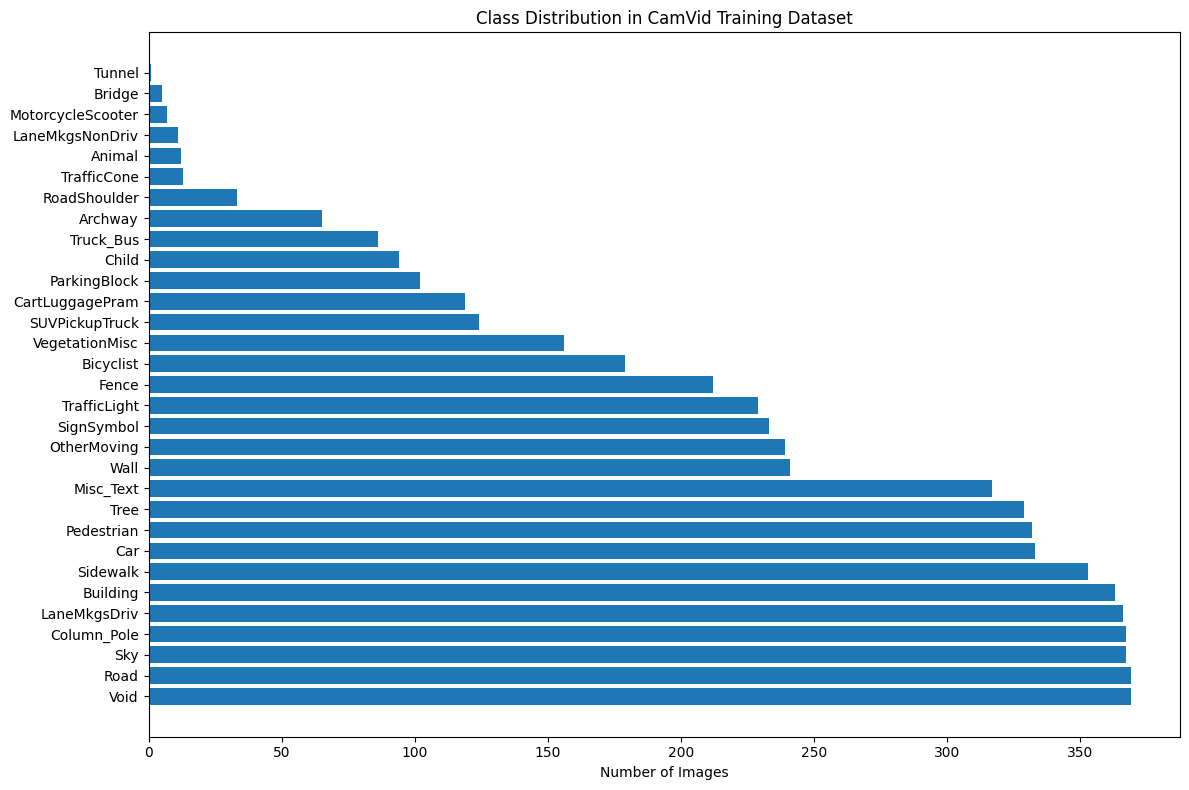

In [13]:
#Visualize Class Distribution

plt.figure(figsize=(12, 8))
labels, counts = zip(*sorted_classes)
plt.barh(range(len(labels)), counts)
plt.yticks(range(len(labels)), labels)
plt.xlabel('Number of Images')
plt.title('Class Distribution in CamVid Training Dataset')
plt.tight_layout()

# Save the figure
plt.savefig("class_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

# Dataset Preprocessing

In [14]:
# Merge 32 classes into 12 simplified classes for autonomous driving

class_merge_mapping = {
    # Ignore class
    "Void": "Ignore",
    
    # Road infrastructure
    "Road": "Road",
    "RoadShoulder": "Road",
    "LaneMkgsDriv": "Road",
    "LaneMkgsNonDriv": "Road",
    
    # Walkable areas
    "Sidewalk": "Sidewalk",
    "ParkingBlock": "Sidewalk",
    
    # Sky
    "Sky": "Sky",
    
    # Buildings and structures
    "Building": "Building",
    "Wall": "Building",
    "Fence": "Building",
    "Tunnel": "Building",
    "Bridge": "Building",
    "Archway": "Building",
    
    # Vegetation
    "Tree": "Vegetation",
    "VegetationMisc": "Vegetation",
    
    # Vehicles
    "Car": "Vehicle",
    "SUVPickupTruck": "Vehicle",
    "Truck_Bus": "Vehicle",
    "Train": "Vehicle",
    
    # Vulnerable road users
    "Pedestrian": "Person",
    "Child": "Person",
    "Bicyclist": "Cyclist",
    "MotorcycleScooter": "Cyclist",
    
    # Street furniture
    "Column_Pole": "Pole",
    "TrafficLight": "TrafficLight",
    "TrafficCone": "TrafficSign",
    "SignSymbol": "TrafficSign",
    "Misc_Text": "TrafficSign",
    
    # Moving objects
    "CartLuggagePram": "Object",
    "OtherMoving": "Object",
    "Animal": "Object"

}

In [15]:
# Create merged class list with IDs
merged_classes = {
    "Ignore": 0,
    "Road": 1,
    "Sidewalk": 2,
    "Building": 3,
    "Pole": 4,
    "TrafficLight": 5,
    "TrafficSign": 6,
    "Vegetation": 7,
    "Sky": 8,
    "Person": 9,
    "Cyclist": 10,
    "Vehicle": 11,
    "Object": 12
}

print("Merged Class Mapping:")
print("-" * 50)
for merged_class, class_id in merged_classes.items():
    print(f"{class_id:2d}: {merged_class}")

Merged Class Mapping:
--------------------------------------------------
 0: Ignore
 1: Road
 2: Sidewalk
 3: Building
 4: Pole
 5: TrafficLight
 6: TrafficSign
 7: Vegetation
 8: Sky
 9: Person
10: Cyclist
11: Vehicle
12: Object


In [16]:
#Create Color to Merged Class ID Mapping

color_to_merged_id = {}

for color, original_class in camvid_classes.items():
    merged_class = class_merge_mapping[original_class]
    merged_id = merged_classes[merged_class]
    color_to_merged_id[color] = merged_id

print(f"\nTotal color mappings created: {len(color_to_merged_id)}")


Total color mappings created: 32


In [17]:
# Function to Convert RGB Mask to Class ID Mask

def convert_rgb_mask_to_ids(rgb_mask, color_to_id_map):
    
    height, width, _ = rgb_mask.shape
    id_mask = np.zeros((height, width), dtype=np.uint8)
    
    for color, class_id in color_to_id_map.items():
        mask = np.all(rgb_mask == color, axis=-1)
        id_mask[mask] = class_id
    
    return id_mask

In [18]:
# Process and Save Preprocessed Masks

def preprocess_dataset(data_dir, output_dir, split='train'):
    input_mask_dir = os.path.join(data_dir, f'{split}_labels')
    output_mask_dir = os.path.join(output_dir, f'{split}_labels_processed')
    
    os.makedirs(output_mask_dir, exist_ok=True)
    
    mask_files = os.listdir(input_mask_dir)
    total_files = len(mask_files)
    
    print(f"\nProcessing {split} set: {total_files} masks")
    print("=" * 50)
    
    for idx, filename in enumerate(mask_files, 1):
        if idx % 50 == 0:
            print(f"Processed {idx}/{total_files} masks...")
        
        # Load RGB mask
        mask_path = os.path.join(input_mask_dir, filename)
        rgb_mask = np.array(Image.open(mask_path).convert('RGB'))
        
        # Convert to class IDs
        id_mask = convert_rgb_mask_to_ids(rgb_mask, color_to_merged_id)
        
        # Save as PNG
        output_path = os.path.join(output_mask_dir, filename)
        Image.fromarray(id_mask).save(output_path)
    
    print(f"Completed: Saved {total_files} preprocessed masks to {output_mask_dir}")
    return output_mask_dir

In [19]:
# Calculate New Class Distribution

def calculate_merged_class_distribution(processed_mask_dir):
   
    class_pixel_counts = defaultdict(int)
    mask_files = os.listdir(processed_mask_dir)
    
    print("\nCalculating merged class distribution...")
    print("=" * 50)
    
    for idx, filename in enumerate(mask_files, 1):
        if idx % 50 == 0:
            print(f"Analyzed {idx}/{len(mask_files)} masks...")
        
        mask_path = os.path.join(processed_mask_dir, filename)
        mask = np.array(Image.open(mask_path))
        
        unique, counts = np.unique(mask, return_counts=True)
        for class_id, count in zip(unique, counts):
            class_pixel_counts[class_id] += count
    
    return class_pixel_counts


def display_class_distribution(class_pixel_counts, merged_classes):
    
    id_to_class = {v: k for k, v in merged_classes.items()}
    total_pixels = sum(class_pixel_counts.values())
    
    print("\nMerged Class Distribution (Pixel-level):")
    print("=" * 50)
    
    sorted_counts = sorted(class_pixel_counts.items(), key=lambda x: x[1], reverse=True)
    
    for class_id, pixel_count in sorted_counts:
        class_name = id_to_class.get(class_id, f"Unknown_{class_id}")
        percentage = (pixel_count / total_pixels) * 100
        print(f"{class_name:15s} (ID {class_id:2d}): {pixel_count:10d} pixels ({percentage:5.2f}%)")
    
    print(f"\nTotal pixels: {total_pixels:,}")

In [20]:
#Visualize Original vs Preprocessed Masks

def visualize_comparison(data_dir, processed_mask_dir, num_samples=4):
    """
    Visualize original RGB masks vs preprocessed class ID masks.
    
    Args:
        data_dir: path to CamVid dataset
        processed_mask_dir: path to preprocessed masks
        num_samples: number of samples to display
    """
    original_mask_dir = os.path.join(data_dir, 'train_labels')
    mask_files = os.listdir(original_mask_dir)[:num_samples]
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, num_samples*3))
    
    for idx, filename in enumerate(mask_files):
        # Load original RGB mask
        original_path = os.path.join(original_mask_dir, filename)
        original_mask = Image.open(original_path).convert('RGB')
        
        # Load preprocessed ID mask
        processed_path = os.path.join(processed_mask_dir, filename)
        processed_mask = np.array(Image.open(processed_path))
        
        # Display
        axes[idx, 0].imshow(original_mask)
        axes[idx, 0].set_title(f'Original RGB Mask - {filename}')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(processed_mask, cmap='tab20')
        axes[idx, 1].set_title(f'Preprocessed Class IDs (13 classes)')
        axes[idx, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


Processing train set: 369 masks
Processed 50/369 masks...
Processed 100/369 masks...
Processed 150/369 masks...
Processed 200/369 masks...
Processed 250/369 masks...
Processed 300/369 masks...
Processed 350/369 masks...
Completed: Saved 369 preprocessed masks to /kaggle/working/camvid_preprocessed/train_labels_processed

Processing val set: 100 masks
Processed 50/100 masks...
Processed 100/100 masks...
Completed: Saved 100 preprocessed masks to /kaggle/working/camvid_preprocessed/val_labels_processed

Processing test set: 232 masks
Processed 50/232 masks...
Processed 100/232 masks...
Processed 150/232 masks...
Processed 200/232 masks...
Completed: Saved 232 preprocessed masks to /kaggle/working/camvid_preprocessed/test_labels_processed

Calculating merged class distribution...
Analyzed 50/369 masks...
Analyzed 100/369 masks...
Analyzed 150/369 masks...
Analyzed 200/369 masks...
Analyzed 250/369 masks...
Analyzed 300/369 masks...
Analyzed 350/369 masks...

Merged Class Distribution (Pi

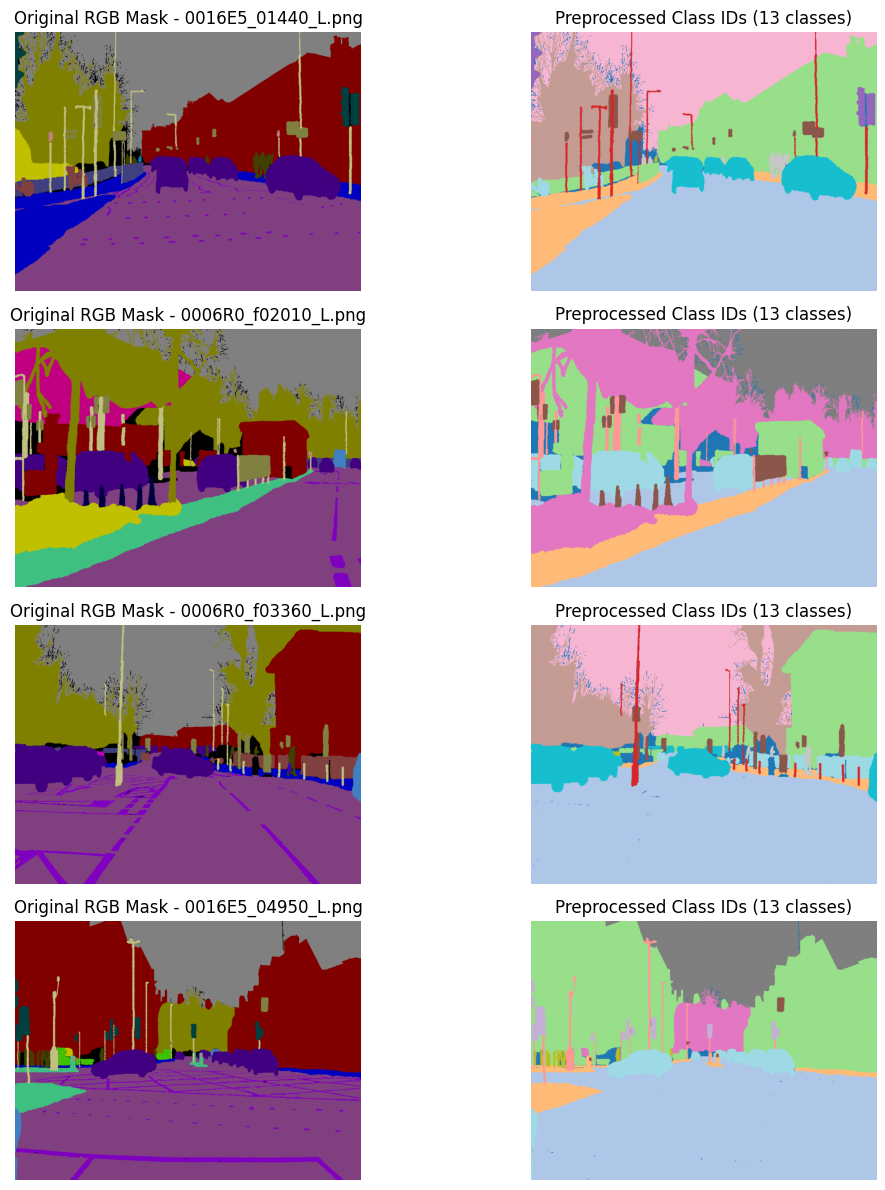


Preprocessing complete!
Preprocessed masks saved to: /kaggle/working/camvid_preprocessed


In [21]:
#Main Execution

if __name__ == "__main__":
    # Configuration
    DATA_DIR = "/kaggle/input/camvid/CamVid"
    OUTPUT_DIR = "/kaggle/working/camvid_preprocessed"
    
    # Process train set
    processed_train_dir = preprocess_dataset(DATA_DIR, OUTPUT_DIR, split='train')

    # Process val set
    processed_val_dir = preprocess_dataset(DATA_DIR, OUTPUT_DIR, split='val')

    # Process test set
    processed_test_dir = preprocess_dataset(DATA_DIR, OUTPUT_DIR, split='test')
    
    # Calculate and display distribution
    class_counts = calculate_merged_class_distribution(processed_train_dir)
    display_class_distribution(class_counts, merged_classes)
    
    # Visualize comparison
    visualize_comparison(DATA_DIR, processed_train_dir, num_samples=4)
    
    print("\nPreprocessing complete!")
    print(f"Preprocessed masks saved to: {OUTPUT_DIR}")

# Training Loop

In [22]:
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [23]:
import torch.optim as optim
import segmentation_models_pytorch as smp
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [24]:
# Configuration

class Config:
    # Paths
    DATA_DIR = "/kaggle/input/camvid/CamVid"
    PROCESSED_DIR = "/kaggle/working/camvid_preprocessed"
    CHECKPOINT_DIR = "/kaggle/working/checkpoints"
    
    # Model Selection - CHANGE HERE TO SWITCH MODELS
    MODEL_NAME = "unet"  # Options: 'unet', 'deeplabv3plus', 'fpn', 'unetplusplus'
    ENCODER_NAME = "resnet50"  # Options: 'resnet50', 'resnet101', 'efficientnet-b0', 'mobilenet_v2'
    ENCODER_WEIGHTS = "imagenet"  # Use pretrained weights
    
    # Dataset
    NUM_CLASSES = 13
    IMAGE_HEIGHT = 480
    IMAGE_WIDTH = 640
    
    # Training
    BATCH_SIZE = 8
    NUM_EPOCHS = 30
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Early stopping
    EARLY_STOPPING_PATIENCE = 15
    
    # LR Scheduler
    LR_SCHEDULER = "reduce_on_plateau"  # Options: 'reduce_on_plateau', 'cosine', 'one_cycle'
    LR_PATIENCE = 5
    LR_FACTOR = 0.5
    
    # Class weights (will be calculated from data)
    CLASS_WEIGHTS = None
    
    # Random seed
    SEED = 42

# Set random seeds
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)

# Create checkpoint directory
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

print(f"Configuration loaded")
print(f"Device: {Config.DEVICE}")
print(f"Model: {Config.MODEL_NAME} with {Config.ENCODER_NAME} encoder")

Configuration loaded
Device: cuda
Model: unet with resnet50 encoder


In [25]:
#Dataset Class

class CamVidDataset(Dataset):
    def __init__(self, data_dir, processed_dir, split='train', transform=None):
        self.image_dir = os.path.join(data_dir, split)
        self.mask_dir = os.path.join(processed_dir, f'{split}_labels_processed')
        self.transform = transform
        
        # Get all image files
        self.images = sorted(os.listdir(self.image_dir))
        
        # Filter only images that have corresponding masks
        self.valid_images = []
        for img_name in self.images:
            mask_name = img_name[:-4] + '_L.png'
            mask_path = os.path.join(self.mask_dir, mask_name)
            if os.path.exists(mask_path):
                self.valid_images.append((img_name, mask_name))
        
        print(f"{split} dataset: {len(self.valid_images)} samples")
    
    def __len__(self):
        return len(self.valid_images)
    
    def __getitem__(self, idx):
        img_name, mask_name = self.valid_images[idx]
        
        # Load image
        img_path = os.path.join(self.image_dir, img_name)
        image = np.array(Image.open(img_path).convert('RGB'))
        
        # Load mask
        mask_path = os.path.join(self.mask_dir, mask_name)
        mask = np.array(Image.open(mask_path))
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        return image, mask.long()

In [26]:
#Data Augmentation

def get_training_augmentation():
    """
    Training augmentation pipeline.
    """
    train_transform = A.Compose([
        A.Resize(Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, p=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    return train_transform

def get_validation_augmentation():
    """
    Validation augmentation pipeline (only resize and normalize).
    """
    val_transform = A.Compose([
        A.Resize(Config.IMAGE_HEIGHT, Config.IMAGE_WIDTH),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    return val_transform

In [27]:
#Calculate Class Weights
def calculate_class_weights(mask_dir, num_classes, ignore_index=0):
    """
    Calculate class weights based on pixel frequency.
    Uses median frequency balancing.
    
    Args:
        mask_dir: directory containing masks
        num_classes: number of classes
        ignore_index: class to ignore (usually 0 for Void/Ignore)
    
    Returns:
        tensor of class weights
    """
    print("\nCalculating class weights...")
    class_counts = np.zeros(num_classes, dtype=np.int64)
    
    mask_files = os.listdir(mask_dir)
    for mask_file in tqdm(mask_files, desc="Analyzing masks"):
        mask_path = os.path.join(mask_dir, mask_file)
        mask = np.array(Image.open(mask_path))
        
        for class_id in range(num_classes):
            class_counts[class_id] += np.sum(mask == class_id)
    
    # Calculate weights using median frequency balancing
    class_counts = class_counts.astype(np.float32)
    class_counts[class_counts == 0] = 1  # Avoid division by zero
    
    median_freq = np.median(class_counts)
    class_weights = median_freq / class_counts
    
    # Set weight for ignore class to 0
    class_weights[ignore_index] = 0.0
    
    print("\nClass weights:")
    for i, weight in enumerate(class_weights):
        print(f"Class {i}: {weight:.4f}")
    
    return torch.FloatTensor(class_weights)

In [28]:
#Model Creation

def create_model(model_name, encoder_name, encoder_weights, num_classes):
    """
    Create segmentation model.
    
    Args:
        model_name: 'unet', 'deeplabv3plus', 'fpn', 'unetplusplus'
        encoder_name: encoder backbone name
        encoder_weights: pretrained weights ('imagenet' or None)
        num_classes: number of output classes
    
    Returns:
        model
    """
    if model_name == 'unet':
        model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=num_classes
        )
    
    elif model_name == 'deeplabv3plus':
        model = smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=num_classes
        )
    
    elif model_name == 'fpn':
        model = smp.FPN(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=num_classes
        )
    
    elif model_name == 'unetplusplus':
        model = smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=num_classes
        )
    
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    return model

In [29]:
#Loss Function

class SegmentationLoss(nn.Module):
    def __init__(self, class_weights=None, ignore_index=0):
        """
        Combined loss for segmentation.
        
        Args:
            class_weights: tensor of class weights
            ignore_index: class to ignore in loss calculation
        """
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
    
    def forward(self, predictions, targets):
        return self.ce_loss(predictions, targets)

In [30]:
#Metrics

class IoUMetric:
    def __init__(self, num_classes, ignore_index=0):
        """
        IoU (Intersection over Union) metric.
        
        Args:
            num_classes: number of classes
            ignore_index: class to ignore
        """
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.reset()
    
    def reset(self):
        self.intersection = np.zeros(self.num_classes)
        self.union = np.zeros(self.num_classes)
    
    def update(self, predictions, targets):
        """
        Update metric with batch predictions.
        
        Args:
            predictions: tensor of shape (B, C, H, W)
            targets: tensor of shape (B, H, W)
        """
        predictions = torch.argmax(predictions, dim=1)
        predictions = predictions.cpu().numpy()
        targets = targets.cpu().numpy()
        
        for class_id in range(self.num_classes):
            if class_id == self.ignore_index:
                continue
            
            pred_mask = predictions == class_id
            target_mask = targets == class_id
            
            intersection = np.logical_and(pred_mask, target_mask).sum()
            union = np.logical_or(pred_mask, target_mask).sum()
            
            self.intersection[class_id] += intersection
            self.union[class_id] += union
    
    def compute(self):
        """
        Compute mean IoU.
        
        Returns:
            mean_iou: mean IoU across all classes (excluding ignore class)
            class_iou: IoU per class
        """
        iou_per_class = np.zeros(self.num_classes)
        valid_classes = 0
        
        for class_id in range(self.num_classes):
            if class_id == self.ignore_index:
                continue
            
            if self.union[class_id] > 0:
                iou_per_class[class_id] = self.intersection[class_id] / self.union[class_id]
                valid_classes += 1
        
        mean_iou = iou_per_class.sum() / valid_classes if valid_classes > 0 else 0
        return mean_iou, iou_per_class

In [31]:
#Training Functions

def train_one_epoch(model, dataloader, criterion, optimizer, device, metric):
    """
    Train for one epoch.
    """
    model.train()
    metric.reset()
    
    running_loss = 0.0
    progress_bar = tqdm(dataloader, desc="Training")
    
    for images, masks in progress_bar:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Update metrics
        running_loss += loss.item()
        metric.update(outputs.detach(), masks.detach())
        
        # Update progress bar
        progress_bar.set_postfix({'loss': loss.item()})
    
    # Compute metrics
    mean_iou, class_iou = metric.compute()
    avg_loss = running_loss / len(dataloader)
    
    return avg_loss, mean_iou


def validate(model, dataloader, criterion, device, metric):
    """
    Validate the model.
    """
    model.eval()
    metric.reset()
    
    running_loss = 0.0
    progress_bar = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for images, masks in progress_bar:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Update metrics
            running_loss += loss.item()
            metric.update(outputs, masks)
            
            # Update progress bar
            progress_bar.set_postfix({'loss': loss.item()})
    
    # Compute metrics
    mean_iou, class_iou = metric.compute()
    avg_loss = running_loss / len(dataloader)
    
    return avg_loss, mean_iou, class_iou

In [32]:
#Learning Rate Scheduler

def get_scheduler(optimizer, scheduler_name, **kwargs):
    """
    Get learning rate scheduler.
    
    Args:
        optimizer: PyTorch optimizer
        scheduler_name: 'reduce_on_plateau', 'cosine', 'one_cycle'
    
    Returns:
        scheduler
    """
    if scheduler_name == 'reduce_on_plateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=kwargs.get('patience', Config.LR_PATIENCE),
            factor=kwargs.get('factor', Config.LR_FACTOR)
        )
    
    elif scheduler_name == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=kwargs.get('T_max', Config.NUM_EPOCHS),
            eta_min=kwargs.get('eta_min', 1e-6)
        )
    
    elif scheduler_name == 'one_cycle':
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=kwargs.get('max_lr', Config.LEARNING_RATE * 10),
            epochs=kwargs.get('epochs', Config.NUM_EPOCHS),
            steps_per_epoch=kwargs.get('steps_per_epoch', 1)
        )
    
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_name}")
    
    return scheduler

In [33]:
#Main Training Loop

def train_model():
    """
    Main training function.
    """
    print("\n" + "="*50)
    print("Starting Training Pipeline")
    print("="*50)
    
    # Create datasets
    train_dataset = CamVidDataset(
        Config.DATA_DIR,
        Config.PROCESSED_DIR,
        split='train',
        transform=get_training_augmentation()
    )
    
    val_dataset = CamVidDataset(
        Config.DATA_DIR,
        Config.PROCESSED_DIR,
        split='val',
        transform=get_validation_augmentation()
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    # Calculate class weights
    train_mask_dir = os.path.join(Config.PROCESSED_DIR, 'train_labels_processed')
    class_weights = calculate_class_weights(train_mask_dir, Config.NUM_CLASSES, ignore_index=0)
    class_weights = class_weights.to(Config.DEVICE)
    
    # Create model
    print(f"\nCreating model: {Config.MODEL_NAME} with {Config.ENCODER_NAME}")
    model = create_model(
        Config.MODEL_NAME,
        Config.ENCODER_NAME,
        Config.ENCODER_WEIGHTS,
        Config.NUM_CLASSES
    )
    model = model.to(Config.DEVICE)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Loss and optimizer
    criterion = SegmentationLoss(class_weights=class_weights, ignore_index=0)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=Config.LEARNING_RATE,
        weight_decay=Config.WEIGHT_DECAY
    )
    
    # Scheduler
    scheduler = get_scheduler(optimizer, Config.LR_SCHEDULER)
    
    # Metrics
    train_metric = IoUMetric(Config.NUM_CLASSES, ignore_index=0)
    val_metric = IoUMetric(Config.NUM_CLASSES, ignore_index=0)
    
    # Training history
    history = {
        'train_loss': [],
        'train_iou': [],
        'val_loss': [],
        'val_iou': []
    }
    
    # Early stopping
    best_val_iou = 0.0
    epochs_without_improvement = 0
    
    # Training loop
    print("\n" + "="*50)
    print("Training Started")
    print("="*50)
    
    for epoch in range(Config.NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{Config.NUM_EPOCHS}")
        print("-" * 50)
        
        # Train
        train_loss, train_iou = train_one_epoch(
            model, train_loader, criterion, optimizer, Config.DEVICE, train_metric
        )
        
        # Validate
        val_loss, val_iou, class_iou = validate(
            model, val_loader, criterion, Config.DEVICE, val_metric
        )
        
        # Update scheduler
        if Config.LR_SCHEDULER == 'reduce_on_plateau':
            scheduler.step(val_loss)
        else:
            scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        
        # Print epoch results
        print(f"\nTrain Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Save best model
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            epochs_without_improvement = 0
            
            checkpoint_path = os.path.join(
                Config.CHECKPOINT_DIR,
                f'best_model_{Config.MODEL_NAME}_{Config.ENCODER_NAME}.pth'
            )
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_iou': val_iou,
                'val_loss': val_loss,
                'class_iou': class_iou
            }, checkpoint_path)
            
            print(f"Saved best model with Val IoU: {val_iou:.4f}")
        else:
            epochs_without_improvement += 1
        
        # Early stopping
        if epochs_without_improvement >= Config.EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break
    
    print("\n" + "="*50)
    print("Training Completed")
    print(f"Best Validation IoU: {best_val_iou:.4f}")
    print("="*50)
    
    return model, history

In [34]:
#Plot Training History

def plot_training_history(history):
    """
    Plot training and validation metrics.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # IoU plot
    axes[1].plot(history['train_iou'], label='Train IoU')
    axes[1].plot(history['val_iou'], label='Val IoU')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('IoU')
    axes[1].set_title('Training and Validation IoU')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.CHECKPOINT_DIR, 'training_history.png'))
    plt.show()


Starting Training Pipeline
train dataset: 369 samples
val dataset: 100 samples

Calculating class weights...


Analyzing masks: 100%|██████████| 369/369 [00:03<00:00, 122.22it/s]



Class weights:
Class 0: 0.0000
Class 1: 0.0856
Class 2: 0.3655
Class 3: 0.1017
Class 4: 2.5338
Class 5: 7.2353
Class 6: 3.3226
Class 7: 0.2398
Class 8: 0.1735
Class 9: 4.0341
Class 10: 5.4845
Class 11: 0.6844
Class 12: 5.2497

Creating model: unet with resnet50


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

...


Train Loss: 0.1621 | Train IoU: 0.7056
Val Loss: 0.4235 | Val IoU: 0.6824
Learning Rate: 0.000050
Saved best model with Val IoU: 0.6824

Epoch 29/30
--------------------------------------------------


Validation: 100%|██████████| 13/13 [00:06<00:00,  2.16it/s, loss=0.68] 



Train Loss: 0.1557 | Train IoU: 0.7163
Val Loss: 0.4232 | Val IoU: 0.6754
Learning Rate: 0.000050

Epoch 30/30
--------------------------------------------------


Validation: 100%|██████████| 13/13 [00:06<00:00,  2.13it/s, loss=0.725]



Train Loss: 0.1551 | Train IoU: 0.7161
Val Loss: 0.4281 | Val IoU: 0.6838
Learning Rate: 0.000050
Saved best model with Val IoU: 0.6838

Training Completed
Best Validation IoU: 0.6838


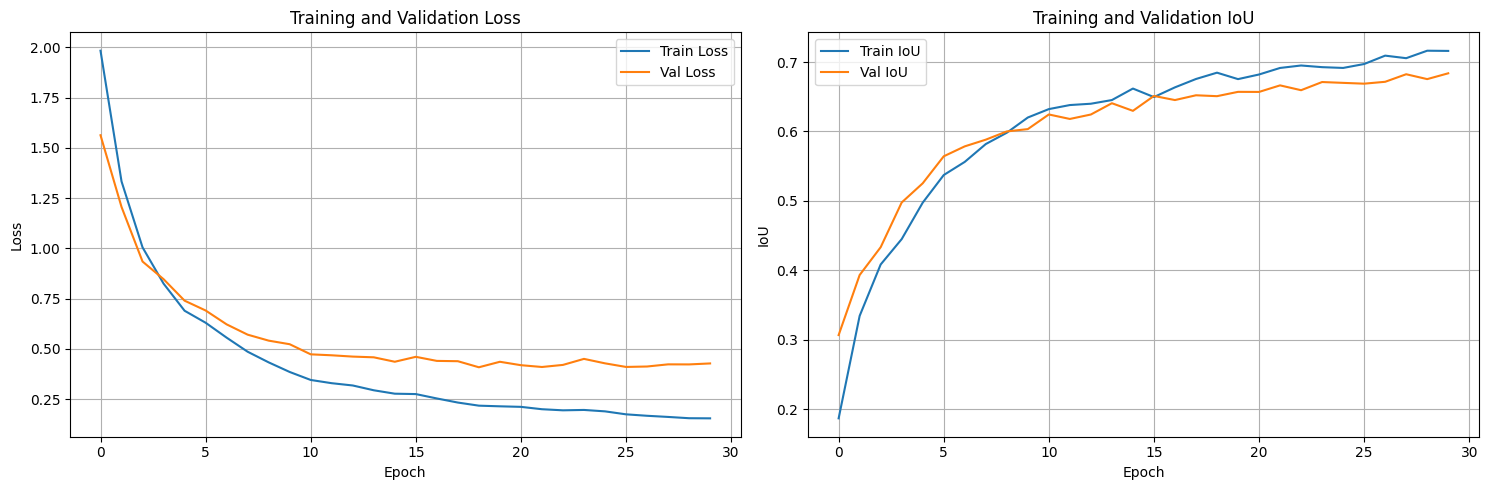

In [35]:
#Execute Training

if __name__ == "__main__":
    # Train model
    model, history = train_model()
    
    # Plot results
    plot_training_history(history)

# Testing

In [36]:
# Test Set Evaluation

def evaluate_test_set(model, test_loader, num_classes=13, ignore_index=0):
    """
    Evaluate model on test set.
    """
    model.eval()
    
    intersection = np.zeros(num_classes)
    union = np.zeros(num_classes)
    
    print("\nEvaluating on test set...")
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Testing"):
            images = images.to(Config.DEVICE)
            masks = masks.to(Config.DEVICE)
            
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            
            predictions = predictions.cpu().numpy()
            masks = masks.cpu().numpy()
            
            for class_id in range(num_classes):
                if class_id == ignore_index:
                    continue
                
                pred_mask = predictions == class_id
                target_mask = masks == class_id
                
                intersection[class_id] += np.logical_and(pred_mask, target_mask).sum()
                union[class_id] += np.logical_or(pred_mask, target_mask).sum()
    
    iou_per_class = np.zeros(num_classes)
    valid_classes = 0
    
    for class_id in range(num_classes):
        if class_id == ignore_index:
            continue
        if union[class_id] > 0:
            iou_per_class[class_id] = intersection[class_id] / union[class_id]
            valid_classes += 1
    
    mean_iou = iou_per_class.sum() / valid_classes if valid_classes > 0 else 0
    
    return mean_iou, iou_per_class



# Visualization Functions

CLASS_NAMES = [
    "Ignore", "Road", "Sidewalk", "Building", "Pole",
    "TrafficLight", "TrafficSign", "Vegetation", "Sky",
    "Person", "Cyclist", "Vehicle", "Object"
]

CLASS_COLORS = np.array([
    [0, 0, 0],       # Ignore
    [128, 64, 128],  # Road
    [244, 35, 232],  # Sidewalk
    [70, 70, 70],    # Building
    [153, 153, 153], # Pole
    [250, 170, 30],  # TrafficLight
    [220, 220, 0],   # TrafficSign
    [107, 142, 35],  # Vegetation
    [70, 130, 180],  # Sky
    [220, 20, 60],   # Person
    [255, 0, 0],     # Cyclist
    [0, 0, 142],     # Vehicle
    [119, 11, 32]    # Object
])

def mask_to_rgb(mask, colors):
    """
    Convert class ID mask to RGB.
    """
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_id in range(len(colors)):
        rgb[mask == class_id] = colors[class_id]
    
    return rgb


def visualize_predictions(model, dataset, num_samples=8):
    """
    Visualize predictions on random samples.
    """
    model.eval()
    
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples*4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            image, mask = dataset[sample_idx]
            
            image_tensor = image.unsqueeze(0).to(Config.DEVICE)
            output = model(image_tensor)
            prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
            
            image_np = image.permute(1, 2, 0).cpu().numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            image_np = std * image_np + mean
            image_np = np.clip(image_np, 0, 1)
            
            mask_rgb = mask_to_rgb(mask.numpy(), CLASS_COLORS)
            pred_rgb = mask_to_rgb(prediction, CLASS_COLORS)
            
            axes[idx, 0].imshow(image_np)
            axes[idx, 0].set_title('Original Image')
            axes[idx, 0].axis('off')
            
            axes[idx, 1].imshow(mask_rgb)
            axes[idx, 1].set_title('Ground Truth')
            axes[idx, 1].axis('off')
            
            axes[idx, 2].imshow(pred_rgb)
            axes[idx, 2].set_title('Prediction')
            axes[idx, 2].axis('off')
    
    plt.tight_layout()
    save_path = os.path.join(Config.CHECKPOINT_DIR, 'predictions_visualization.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\nPredictions saved to: {save_path}")
    plt.show()


# Inference Speed Test

def test_inference_speed(model, test_loader, num_iterations=100):
    """
    Measure inference speed.
    """
    import time
    
    model.eval()
    times = []
    
    print("\nTesting inference speed...")
    with torch.no_grad():
        for i, (images, _) in enumerate(test_loader):
            if i >= num_iterations:
                break
            
            images = images.to(Config.DEVICE)
            
            start_time = time.time()
            outputs = model(images)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end_time = time.time()
            
            times.append(end_time - start_time)
    
    avg_time = np.mean(times)
    fps = Config.BATCH_SIZE / avg_time
    
    print(f"\nInference Speed Results:")
    print(f"Average time per batch ({Config.BATCH_SIZE} images): {avg_time*1000:.2f} ms")
    print(f"FPS: {fps:.2f}")
    print(f"Time per image: {avg_time/Config.BATCH_SIZE*1000:.2f} ms")
    
    return avg_time, fps


#Complete Test Evaluation Pipeline

def run_test_evaluation(checkpoint_path):
    """
    Complete test evaluation pipeline.
    """
    print("\n" + "="*60)
    print("TEST EVALUATION PIPELINE")
    print("="*60)
    
    # Load model
    print(f"\nLoading checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    
    model = create_model(
        Config.MODEL_NAME,
        Config.ENCODER_NAME,
        None,
        Config.NUM_CLASSES
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(Config.DEVICE)
    
    # Create test dataset
    test_dataset = CamVidDataset(
        Config.DATA_DIR,
        Config.PROCESSED_DIR,
        split='test',
        transform=get_validation_augmentation()
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        num_workers=4
    )
    
    print(f"Test dataset: {len(test_dataset)} samples\n")
    
    # 1. Evaluate metrics
    mean_iou, class_iou = evaluate_test_set(model, test_loader)
    
    print("\n" + "="*60)
    print("TEST RESULTS")
    print("="*60)
    print(f"\nMean IoU: {mean_iou:.4f}\n")
    print("Per-Class IoU:")
    print("-"*60)
    for i, (name, iou) in enumerate(zip(CLASS_NAMES, class_iou)):
        if i != 0:
            print(f"{name:20s}: {iou:.4f}")
    print("="*60)
    
    # 2. Visualize predictions
    print("\nGenerating prediction visualizations...")
    visualize_predictions(model, test_dataset, num_samples=8)
    
    # 3. Test inference speed
    avg_time, fps = test_inference_speed(model, test_loader)
    
    # 4. Save results
    results_file = os.path.join(Config.CHECKPOINT_DIR, 'test_results.txt')
    with open(results_file, 'w') as f:
        f.write("="*60 + "\n")
        f.write("TEST SET EVALUATION RESULTS\n")
        f.write("="*60 + "\n\n")
        f.write(f"Model: {Config.MODEL_NAME}\n")
        f.write(f"Encoder: {Config.ENCODER_NAME}\n\n")
        f.write(f"Mean IoU: {mean_iou:.4f}\n\n")
        f.write("Per-Class IoU:\n")
        f.write("-"*60 + "\n")
        for i, (name, iou) in enumerate(zip(CLASS_NAMES, class_iou)):
            if i != 0:
                f.write(f"{name:20s}: {iou:.4f}\n")
        f.write("\n" + "="*60 + "\n")
        f.write("Inference Speed:\n")
        f.write(f"FPS: {fps:.2f}\n")
        f.write(f"Time per image: {avg_time/Config.BATCH_SIZE*1000:.2f} ms\n")
        f.write("="*60 + "\n")
    
    print(f"\nResults saved to: {results_file}")
    print("\nTest evaluation complete!")
    
    return mean_iou, class_iou, fps





TEST EVALUATION PIPELINE

Loading checkpoint: /kaggle/working/checkpoints/best_model_unet_resnet50.pth
test dataset: 232 samples
Test dataset: 232 samples


Evaluating on test set...


Testing: 100%|██████████| 29/29 [00:13<00:00,  2.15it/s]



TEST RESULTS

Mean IoU: 0.6500

Per-Class IoU:
------------------------------------------------------------
Road                : 0.9093
Sidewalk            : 0.7939
Building            : 0.8307
Pole                : 0.2875
TrafficLight        : 0.5791
TrafficSign         : 0.4122
Vegetation          : 0.7634
Sky                 : 0.9191
Person              : 0.4306
Cyclist             : 0.5928
Vehicle             : 0.8417
Object              : 0.4397

Generating prediction visualizations...

Predictions saved to: /kaggle/working/checkpoints/predictions_visualization.png


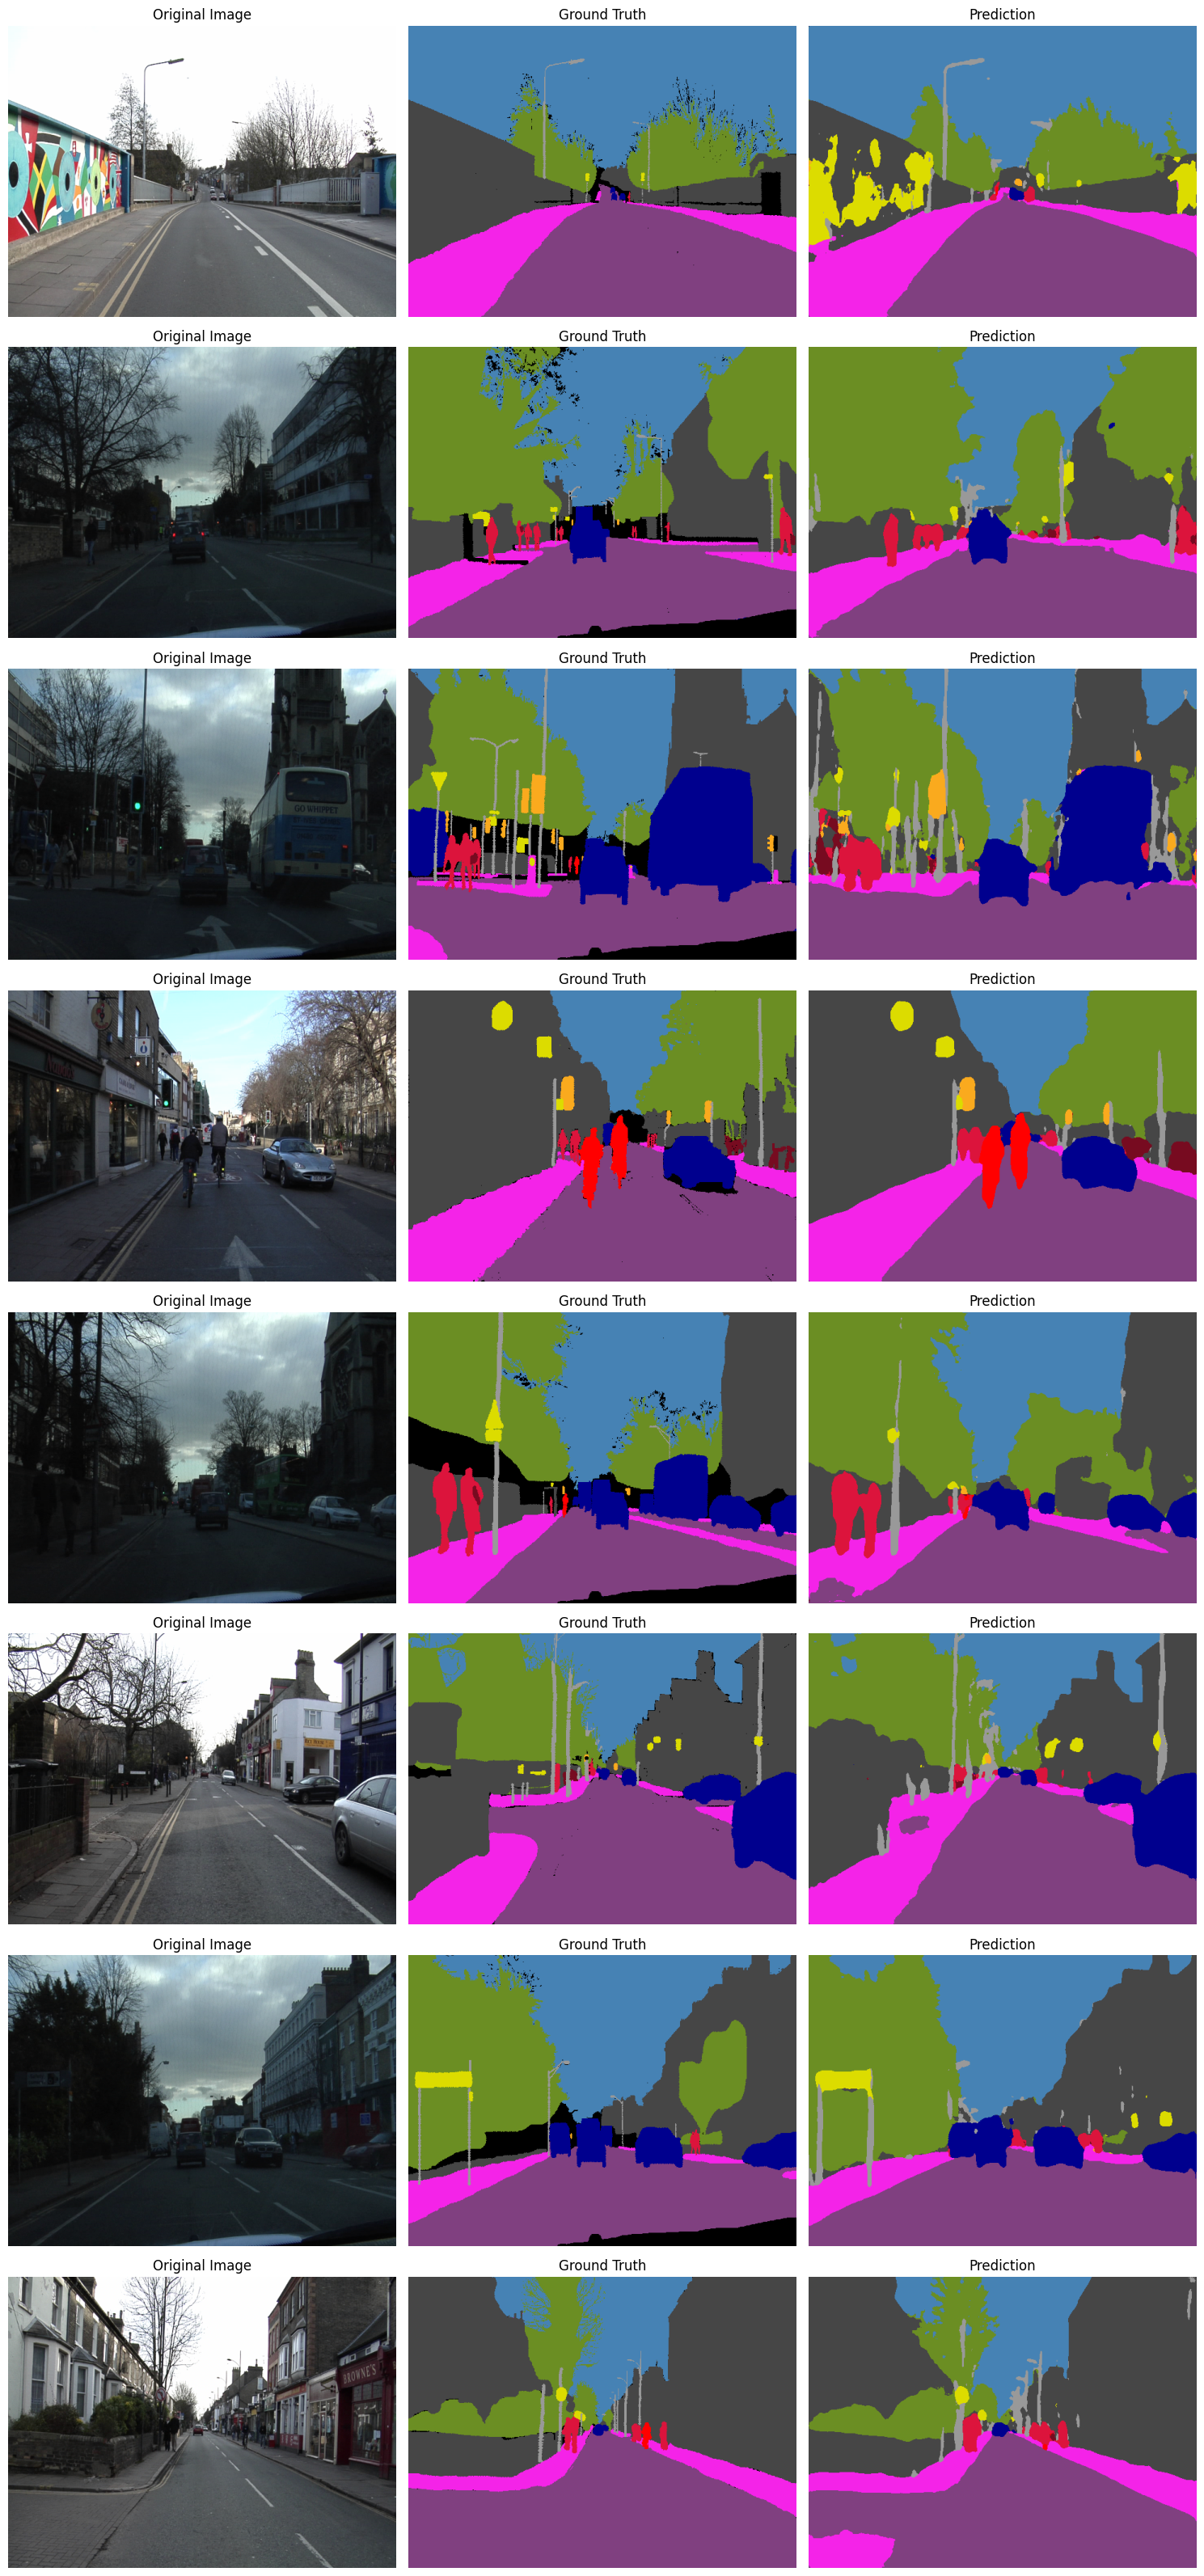


Testing inference speed...

Inference Speed Results:
Average time per batch (8 images): 287.24 ms
FPS: 27.85
Time per image: 35.90 ms

Results saved to: /kaggle/working/checkpoints/test_results.txt

Test evaluation complete!


In [37]:

# Test Evaluation
checkpoint_path = os.path.join(
    Config.CHECKPOINT_DIR,
    f'best_model_{Config.MODEL_NAME}_{Config.ENCODER_NAME}.pth'
)
test_iou, test_class_iou, test_fps = run_test_evaluation(checkpoint_path)